In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [3]:
class PipelineState(TypedDict):
    text: str
    word_count: int
    uppercase_text: str
    result_summary: str

In [4]:
def count_words_node(state: PipelineState):
    words = len(state["text"].split())
    return {"word_count": words}

In [5]:
def uppercase_node(state: PipelineState):
    upper = state["text"].upper()
    return {"uppercase_text": upper}

In [15]:
def summarize_node(state: PipelineState):
    summary = f"Processed : '{state['uppercase_text']}' | Total Words: {state['word_count']}"
    return {"result_summary": summary}

In [16]:
graph = StateGraph(PipelineState)
graph.add_node('count_words', count_words_node)
graph.add_node('uppercase', uppercase_node)
graph.add_node('summarize', summarize_node)

graph.add_edge(START, 'count_words')
graph.add_edge(START, 'uppercase')
graph.add_edge('count_words', 'summarize')
graph.add_edge('uppercase', 'summarize')
graph.add_edge('summarize', END)


In [17]:
workflow = graph.compile()

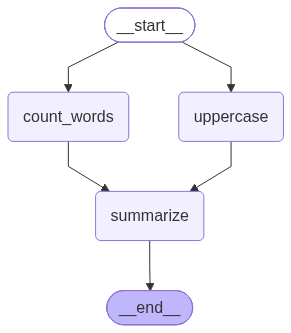

In [13]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [18]:
initial_state = {
    "text": "Hello, The Captial city Of Bangladesh is Dhaka. It is a beautiful city with a rich history and vibrant culture. The city is known for its bustling markets, delicious street food, and historical landmarks. Dhaka is also home to many universities, museums, and cultural institutions that showcase the country's heritage and artistic achievements.",
}

final_state = workflow.invoke(initial_state)

final_state


{'text': "Hello, The Captial city Of Bangladesh is Dhaka. It is a beautiful city with a rich history and vibrant culture. The city is known for its bustling markets, delicious street food, and historical landmarks. Dhaka is also home to many universities, museums, and cultural institutions that showcase the country's heritage and artistic achievements.",
 'word_count': 53,
 'uppercase_text': "HELLO, THE CAPTIAL CITY OF BANGLADESH IS DHAKA. IT IS A BEAUTIFUL CITY WITH A RICH HISTORY AND VIBRANT CULTURE. THE CITY IS KNOWN FOR ITS BUSTLING MARKETS, DELICIOUS STREET FOOD, AND HISTORICAL LANDMARKS. DHAKA IS ALSO HOME TO MANY UNIVERSITIES, MUSEUMS, AND CULTURAL INSTITUTIONS THAT SHOWCASE THE COUNTRY'S HERITAGE AND ARTISTIC ACHIEVEMENTS.",
 'result_summary': "Processed : 'HELLO, THE CAPTIAL CITY OF BANGLADESH IS DHAKA. IT IS A BEAUTIFUL CITY WITH A RICH HISTORY AND VIBRANT CULTURE. THE CITY IS KNOWN FOR ITS BUSTLING MARKETS, DELICIOUS STREET FOOD, AND HISTORICAL LANDMARKS. DHAKA IS ALSO HOME 